# CIFAR-10 Image Classification: CNN & Transfer Learning

This notebook covers the full pipeline for classifying CIFAR-10 images:

1. **Data Loading** - Load CIFAR-10 from raw pickle files
2. **Exploratory Data Analysis** - Visualize samples and class distributions
3. **Preprocessing** - Normalize pixel values
4. **Custom CNN** - Train and evaluate a CNN built from scratch
5. **Transfer Learning** - MobileNetV2 and ResNet50 pretrained models
6. **Model Comparison** - Side-by-side performance analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from ih_cnn.utils import unpickle, plot_training_curves

In [2]:
# Check GPU availability (Apple Silicon Metal)
print("TensorFlow version:", tf.__version__)
print("Available devices:", tf.config.list_physical_devices())
print("GPU device:", tf.config.list_physical_devices("GPU"))
print("GPU type:", tf.config.experimental.get_device_details(tf.config.list_physical_devices("GPU")[0]))

# Enable mixed precision for better Metal GPU performance
tf.keras.mixed_precision.set_global_policy("mixed_float16")

TensorFlow version: 2.16.2
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU type: {'device_name': 'METAL'}


## 1. Data Loading

The CIFAR-10 dataset is stored as pickled Python dictionaries. Each batch file contains:
- `b'data'`: a 10000x3072 NumPy array (each row is a 32x32x3 image in channel-first order)
- `b'labels'`: a list of 10000 integer labels (0-9)
- `b'filenames'`: original filenames

We load all 5 training batches and the test batch, then reshape from flat arrays to (N, 32, 32, 3).

In [ ]:
DATA_DIR = "data/cifar-10-batches-py"

In [4]:
# Load training batches
train_data, train_labels = [], []
for i in range(1, 6):
    batch = unpickle(os.path.join(DATA_DIR, f"data_batch_{i}"))
    train_data.append(batch[b"data"])
    train_labels.extend(batch[b"labels"])

X_train = np.concatenate(train_data)
y_train = np.array(train_labels)

# Load test batch
test_batch = unpickle(os.path.join(DATA_DIR, "test_batch"))
X_test = test_batch[b"data"]
y_test = np.array(test_batch[b"labels"])

# Load class names
meta = unpickle(os.path.join(DATA_DIR, "batches.meta"))
class_names = [name.decode("utf-8") for name in meta[b"label_names"]]

# Reshape from (N, 3072) -> (N, 32, 32, 3)
# Data is stored channel-first: [R...R, G...G, B...B]
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(f"Training set: {X_train.shape}, labels: {y_train.shape}")
print(f"Test set:     {X_test.shape}, labels: {y_test.shape}")
print(f"Classes:      {class_names}")
print(f"Pixel range:  [{X_train.min()}, {X_train.max()}]")

Training set: (50000, 32, 32, 3), labels: (50000,)
Test set:     (10000, 32, 32, 3), labels: (10000,)
Classes:      ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel range:  [0, 255]


## 2. Exploratory Data Analysis

### 2.1 Target Class Distribution

Let's verify that the dataset is balanced across all 10 classes.

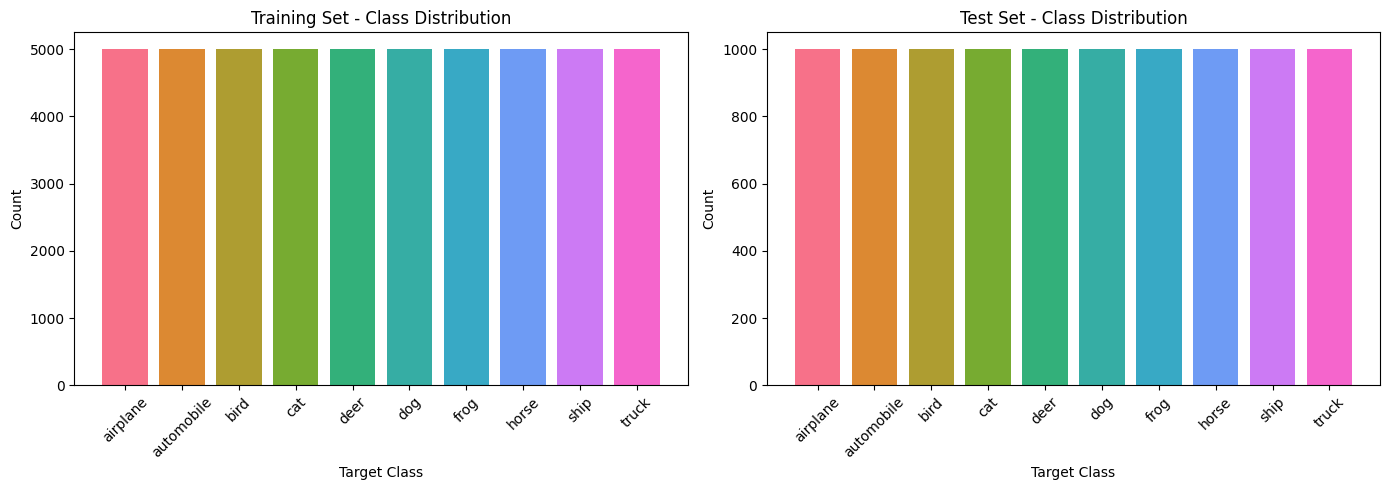

In [5]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes, [y_train, y_test], ["Training Set", "Test Set"]):
    unique, counts = np.unique(labels, return_counts=True)
    ax.bar([class_names[i] for i in unique], counts, color=sns.color_palette("husl", 10))
    ax.set_title(f"{title} - Class Distribution")
    ax.set_xlabel("Target Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 2.2 Sample Images

Display 5 random images per class to peak at the data.

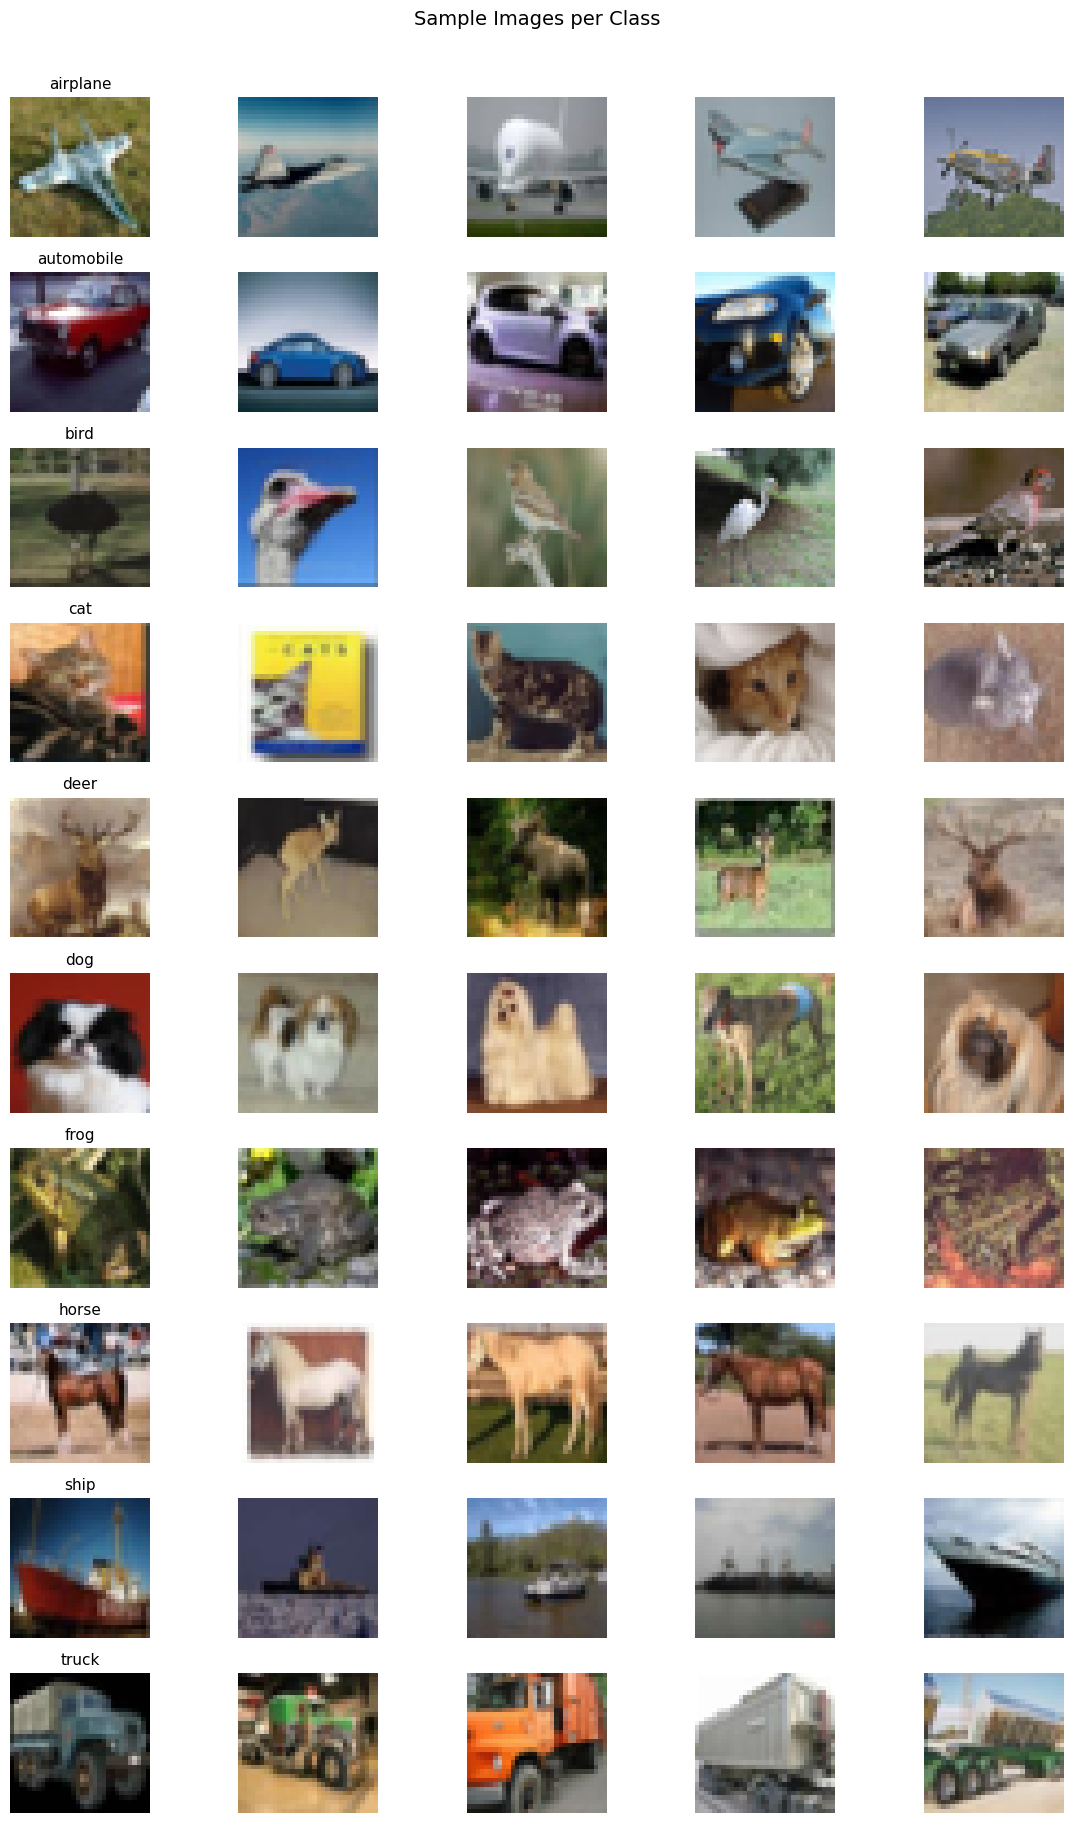

In [6]:
_, axes = plt.subplots(10, 5, figsize=(12, 18))

for class_idx in range(10):
    indices = np.where(y_train == class_idx)[0]
    samples = np.random.choice(indices, 5, replace=False)

    for col, idx in enumerate(samples):
        axes[class_idx, col].imshow(X_train[idx])
        axes[class_idx, col].axis("off")
        if col == 0:
            axes[class_idx, col].set_title(class_names[class_idx], fontsize=11)

plt.suptitle("Sample Images per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Pixel Statistics

Examining per-channel (RGB) mean and standard deviation, plus the overall pixel value distribution.

Per-channel statistics (training set):
 - Red: mean=125.31, std=62.99
 - Green: mean=122.95, std=62.09
 - Blue: mean=113.87, std=66.70


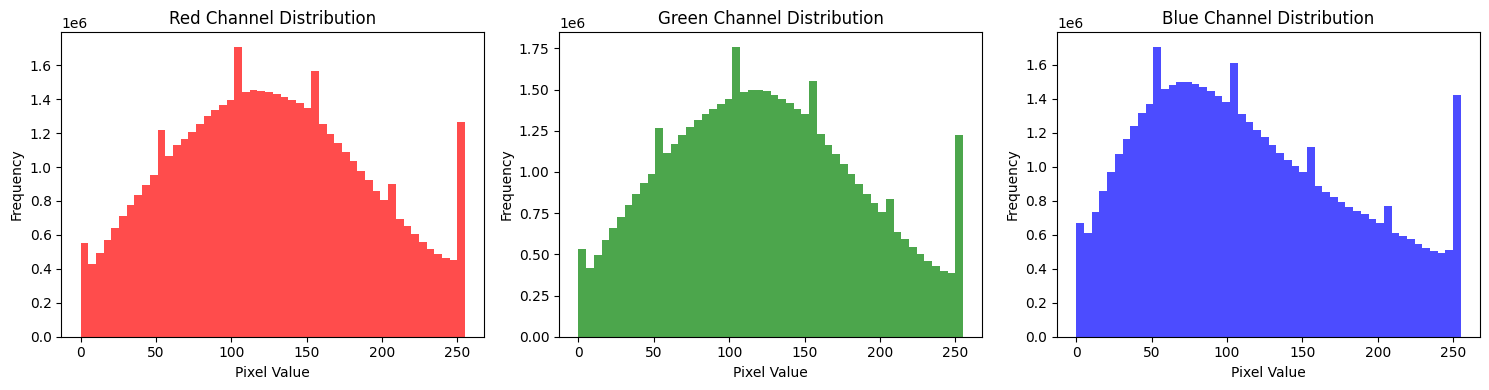

In [7]:
# Per-channel statistics
channels = ["Red", "Green", "Blue"]
print("Per-channel statistics (training set):")
for i, ch in enumerate(channels):
    mean = X_train[:, :, :, i].mean()
    std = X_train[:, :, :, i].std()
    print(f" - {ch}: mean={mean:.2f}, std={std:.2f}")

# Pixel value distribution
_, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["red", "green", "blue"]

for i, (ax, ch, color) in enumerate(zip(axes, channels, colors)):
    ax.hist(X_train[:, :, :, i].ravel(), bins=50, color=color, alpha=0.7)
    ax.set_title(f"{ch} Channel Distribution")
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Preprocessing

Normalize pixel values from [0, 255] to [0, 1] by dividing by 255. This helps with training stability and convergence.

In [8]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

print(f"Normalized pixel range: [{X_train.min()}, {X_train.max()}]")
print(f"X_train dtype: {X_train.dtype}")
print(f"X_test dtype:  {X_test.dtype}")

Normalized pixel range: [0.0, 1.0]
X_train dtype: float32
X_test dtype:  float32


## 4. Custom CNN Model

Training our custom CNN from scratch. The architecture is defined in `models.py` and consists of:
- 2 convolutional blocks (Conv2D + MaxPooling2D)
- Dropout regularization
- Dense classification head

We use **EarlyStopping** to prevent overfitting and **ReduceLROnPlateau** to adaptively lower the learning rate.

In [9]:
from ih_cnn.models import CNN_CIFAR_10

cnn = CNN_CIFAR_10()
cnn.summary()

2026-03-26 19:29:23.782771: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-26 19:29:23.782789: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 19:29:23.782793: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 19:29:23.782806: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 19:29:23.782814: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,619,082 (17.62 MB)

 Trainable params: 4,618,122 (17.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
# Train custom CNN
# cnn.history = cnn.train(
#     X_train,
#     y_train,
#     epochs=50,
#     batch_size=128,
#     validation_split=0.2,
#     callbacks=cnn.callbacks,
# )

# cnn.save_data("cnn_cifar10")

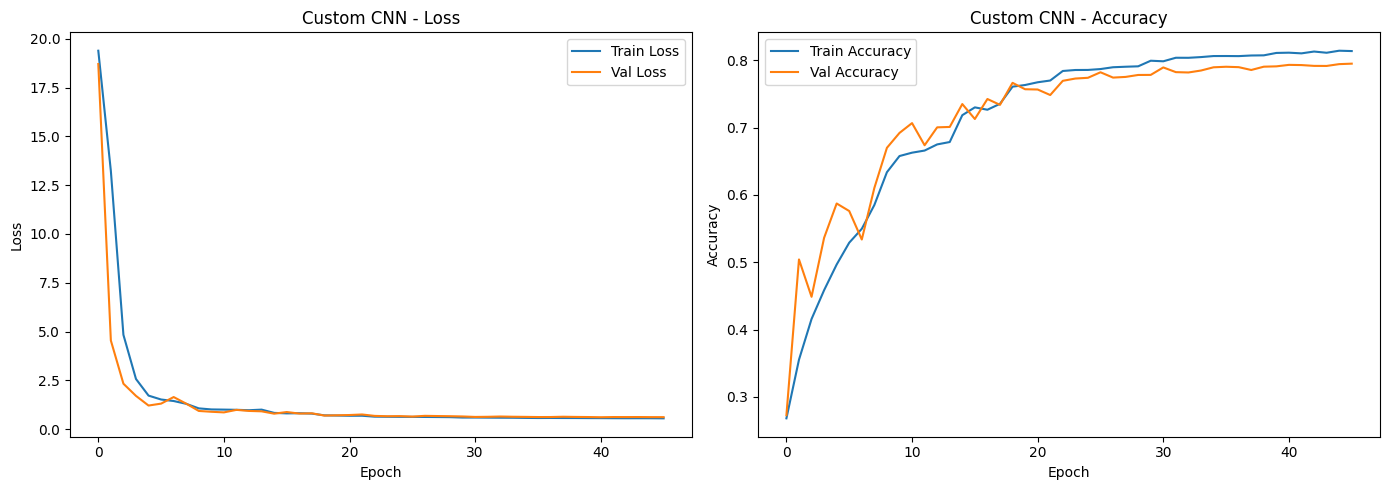

In [11]:
cnn_cifar = CNN_CIFAR_10("models/cnn_cifar10/6ef00fa3-71f6-46fe-b1ab-8c9dc91db350.keras")
plot_training_curves(cnn_cifar.history, title="Custom CNN")

### 4.1 Custom CNN - Evaluation

Evaluating on the held-out test set with accuracy, precision, recall, F1-score, and confusion matrix.

  1/313 ━━━━━━━━━━━━━━━━━━━━ 58s 187ms/step

2026-03-26 19:29:24.523733: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

    airplane       0.81      0.84      0.82      1000
  automobile       0.90      0.90      0.90      1000
        bird       0.76      0.67      0.71      1000
         cat       0.67      0.57      0.62      1000
        deer       0.75      0.76      0.76      1000
         dog       0.75      0.64      0.69      1000
        frog       0.75      0.91      0.82      1000
       horse       0.79      0.84      0.81      1000
        ship       0.89      0.89      0.89      1000
       truck       0.81      0.90      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



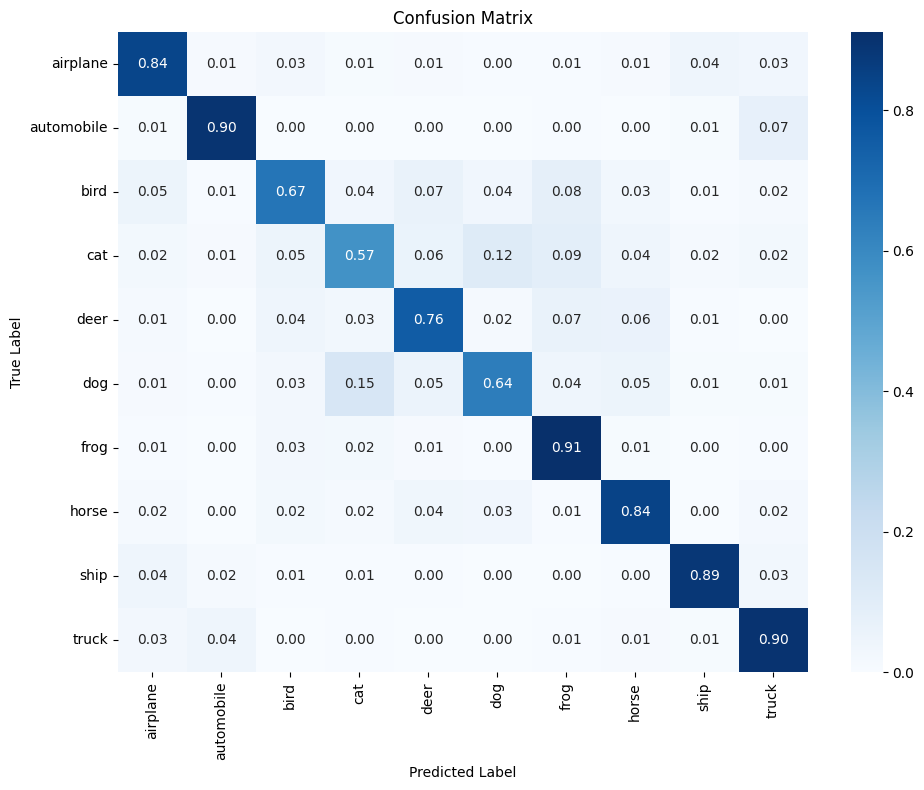

In [12]:
cnn_cifar.evaluate(X_test, y_test)

## 5. Transfer Learning

### 5.1 MobileNetV2

MobileNetV2 is a lightweight architecture pretrained on ImageNet. It natively supports 32x32 input, so no resizing is needed. All pretrained weights are **frozen** - only the new classification head is trained.

In [13]:
from ih_cnn.models import MNV2_CIFAR_10

mobilenet = MNV2_CIFAR_10()
mobilenet.summary()

/Users/rmei/repos/ih-cnn-image-classification/src/ih_cnn/models.py:148: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mnv2 = app.MobileNetV2(include_top=False, weights="imagenet", pooling="avg")


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [14]:
# Train MobileNetV2
# mobilenet.history = mobilenet.train(
#     X_train,
#     y_train,
#     epochs=50,
#     batch_size=128,
#     validation_split=0.2,
#     callbacks=mobilenet.callbacks,
# )
# mobilenet.save_data("mnv2_cifar10")

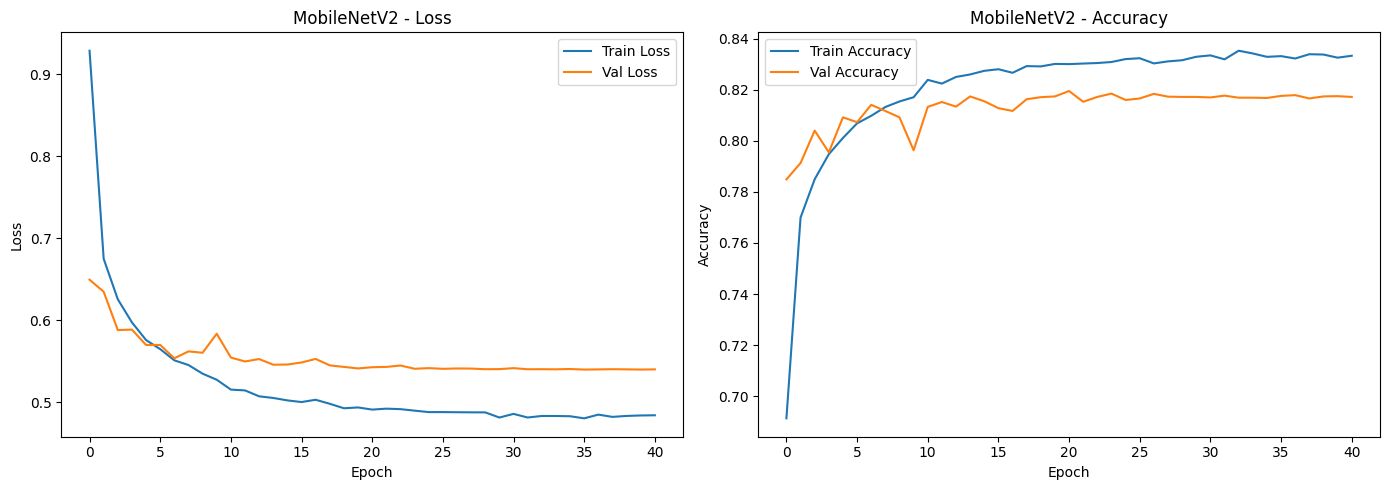

In [15]:
mnv2_cifar = MNV2_CIFAR_10("models/mnv2_cifar10/a62872cb-3774-418a-95a2-fa27210d2adf.keras")
plot_training_curves(mnv2_cifar.history, title="MobileNetV2")

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step
              precision    recall  f1-score   support

    airplane       0.80      0.83      0.82      1000
  automobile       0.90      0.90      0.90      1000
        bird       0.77      0.73      0.75      1000
         cat       0.69      0.69      0.69      1000
        deer       0.74      0.77      0.75      1000
         dog       0.78      0.77      0.77      1000
        frog       0.80      0.84      0.82      1000
       horse       0.84      0.80      0.82      1000
        ship       0.89      0.87      0.88      1000
       truck       0.88      0.89      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



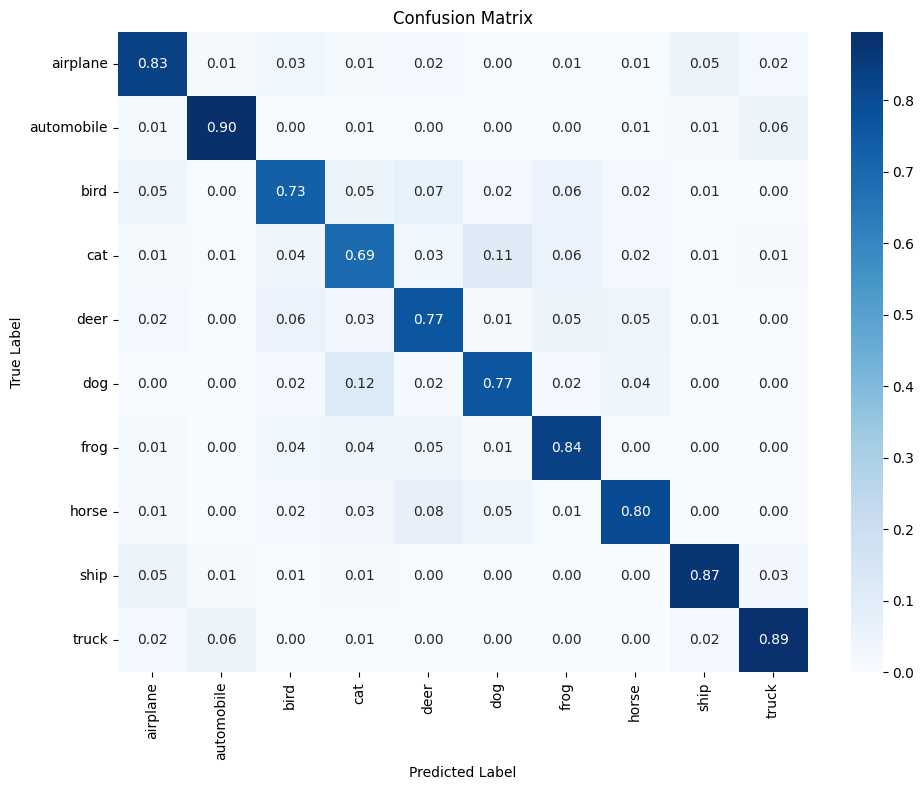

In [16]:
mnv2_cifar.evaluate(X_test, y_test)

### 5.2 ResNet50

ResNet50 is a deeper architecture pretrained on ImageNet. Since it expects larger inputs, our model includes a built-in **Resizing layer** that upscales 32x32 images to 96x96. All pretrained weights are **frozen**.

In [17]:
from ih_cnn.models import RN50_CIFAR_10

resnet = RN50_CIFAR_10()
resnet.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 96, 96, 3) │          0 │ input_layer_4[0]… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 96, 96, 3) │          0 │ resizing_1[0][0]  │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ rescaling_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ rescaling_1[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    524,544 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10)        │      2,570 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,115,850 (91.99 MB)

 Trainable params: 527,626 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [18]:
# resnet.history = resnet.train(
#     X_train, y_train,
#     epochs=50,
#     batch_size=256, # Model tended to overfit a bit, reducing batch size might help
#     validation_split=0.2,
#     callbacks=resnet.callbacks,
# )
# resnet.save_data("rn50_cifar10")

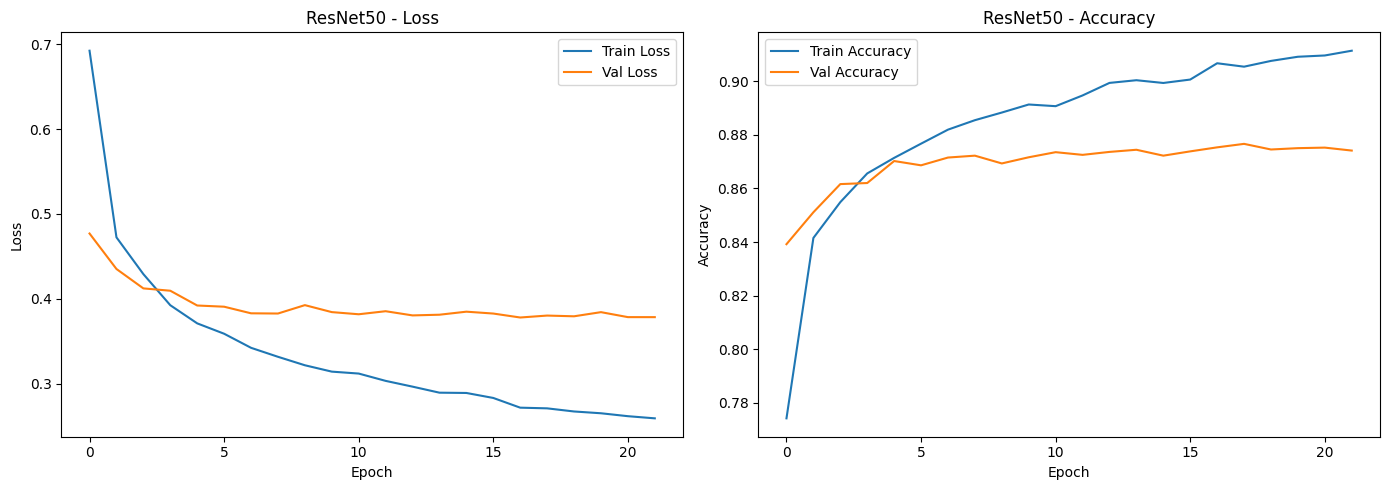

In [19]:
rn50 = RN50_CIFAR_10("models/rn50_cifar10/87bebe27-216f-40b1-bb0e-387aa9c687cc.keras")
plot_training_curves(rn50.history, title="ResNet50")

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step
              precision    recall  f1-score   support

    airplane       0.88      0.90      0.89      1000
  automobile       0.93      0.90      0.91      1000
        bird       0.88      0.84      0.86      1000
         cat       0.75      0.76      0.76      1000
        deer       0.84      0.86      0.85      1000
         dog       0.84      0.81      0.82      1000
        frog       0.88      0.90      0.89      1000
       horse       0.89      0.89      0.89      1000
        ship       0.91      0.93      0.92      1000
       truck       0.91      0.91      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



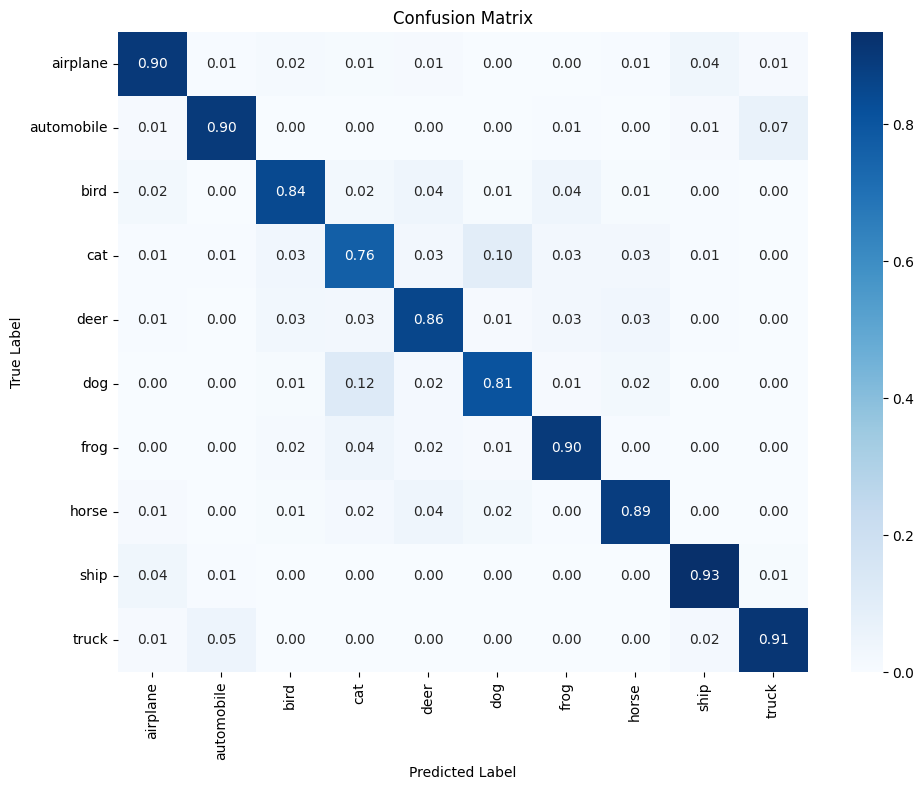

In [20]:
rn50.evaluate(X_test, y_test)

## 6. Model Comparison

Comparing all three models side-by-side on key metrics to understand the trade-offs between building from scratch vs. transfer learning.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Collect predictions from all models
models_dict = {
    "Custom CNN": cnn_cifar,
    "MobileNetV2": mnv2_cifar,
    "ResNet50": rn50,
}

results = []
for name, model in models_dict.items():
    y_pred = np.argmax(model.model.predict(X_test), axis=1)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    })

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step


In [22]:
comparison_df = pd.DataFrame(results).set_index("Model")
comparison_df.style.format("{:.4f}").highlight_max(axis=0, color="green")

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Model,,,,
Custom CNN,0.7906,0.7887,0.7906,0.7873
MobileNetV2,0.8086,0.8091,0.8086,0.8086
ResNet50,0.8699,0.8702,0.8699,0.8699


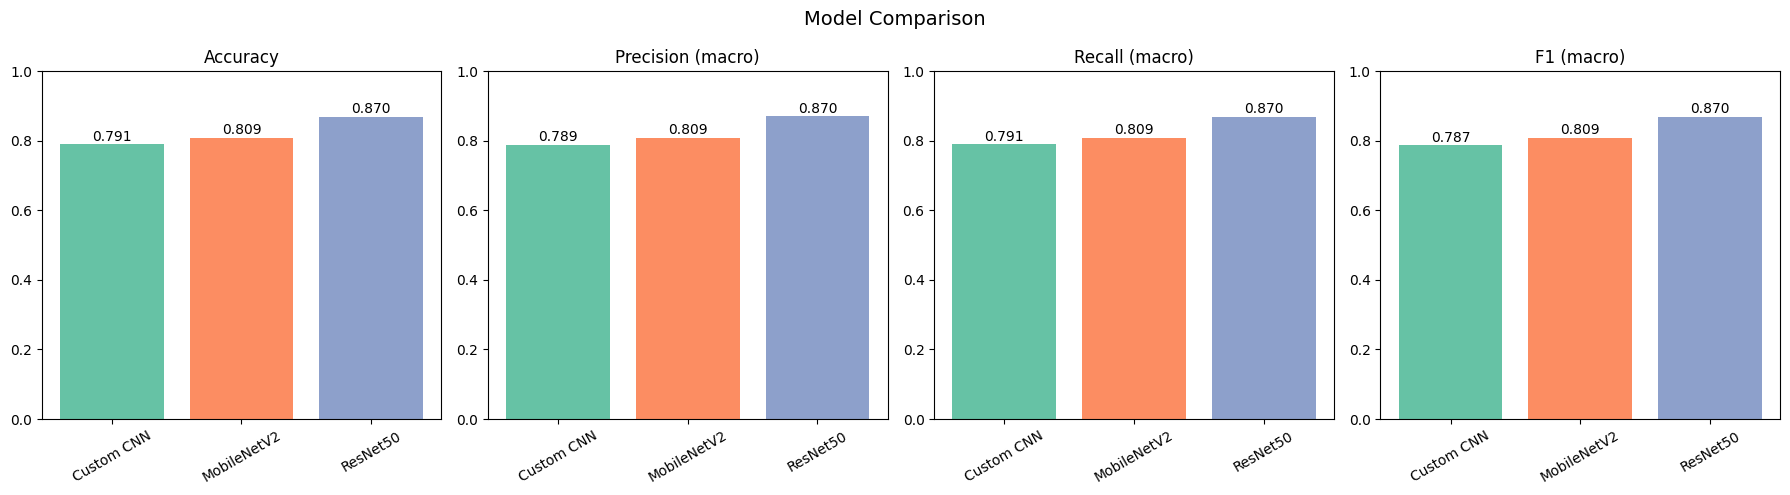

In [23]:
# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
colors = sns.color_palette("Set2", 3)

for ax, metric in zip(axes, metrics):
    values = comparison_df[metric]
    bars = ax.bar(values.index, values.values, color=colors)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=10)

plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Conclusions

### Transfer Learning vs. Custom CNN

**Advantages of Transfer Learning:**
- Pretrained models leverage features learned from millions of ImageNet images, providing a strong starting point even for different tasks
- Typically converges faster since only the classification head needs training
- Often achieves higher accuracy with less training data

**Trade-offs:**
- Pretrained models are larger and require more memory (e.g., ResNet50 has ~23M parameters vs. our CNN's ~4.6M)
- The ImageNet features may not transfer perfectly to CIFAR-10's small 32x32 images, since ImageNet models were trained on 224x224+ images
- MobileNetV2, being lightweight, often strikes the best balance between performance and efficiency. It allows us to have a simpler architecture compared to our custom CNN model, and it performs better (even if not by much) with much less tweaking. It needs upscaling.
- ResNet50 also requires upscaling (32x32 to 96x96), adding computational overhead.

### Key Observations
- The **custom CNN** is the fastest to train and most memory-efficient, but has limited representational capacity and takes a lot of architectural and tuning work to get an acceptable performance
- **MobileNetV2** offers a good balance between training time and performance
- **ResNet50** is the heaviest model; it takes a long time to train (~5x), but the performance is excellent

### Notes for further experimentation
To get even better performance out of the transfer learning models it would be appropriate to fine-tune them: unfreezing the top layers and retraining their weights would most likely allow ResNet50 to pass the 90% test accuracy threshold.